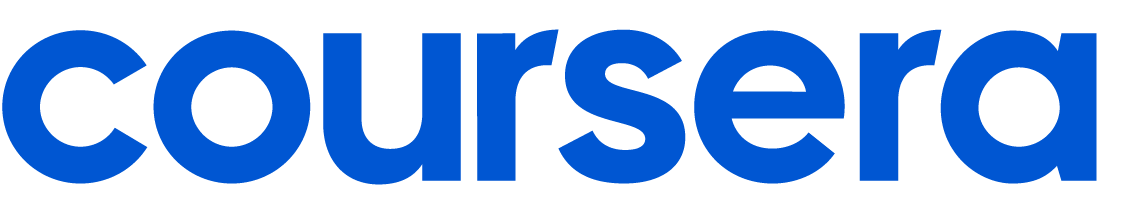

# Welcome to the Data Science Coding Challange!

Test your skills in a real-world coding challenge. Coding Challenges provide CS & DS Coding Competitions with Prizes and achievement badges!

CS & DS learners want to be challenged as a way to evaluate if they’re job ready. So, why not create fun challenges and give winners something truly valuable such as complimentary access to select Data Science courses, or the ability to receive an achievement badge on their Coursera Skills Profile - highlighting their performance to recruiters.

## Introduction

In this challenge, you'll get the opportunity to tackle one of the most industry-relevant maching learning problems with a unique dataset that will put your modeling skills to the test. Subscription services are leveraged by companies across many industries, from fitness to video streaming to retail. One of the primary objectives of companies with subscription services is to decrease churn and ensure that users are retained as subscribers. In order to do this efficiently and systematically, many companies employ machine learning to predict which users are at the highest risk of churn, so that proper interventions can be effectively deployed to the right audience.

In this challenge, we will be tackling the churn prediction problem on a very unique and interesting group of subscribers on a video streaming service! 

Imagine that you are a new data scientist at this video streaming company and you are tasked with building a model that can predict which existing subscribers will continue their subscriptions for another month. We have provided a dataset that is a sample of subscriptions that were initiated in 2021, all snapshotted at a particular date before the subscription was cancelled. Subscription cancellation can happen for a multitude of reasons, including:
* the customer completes all content they were interested in, and no longer need the subscription
* the customer finds themselves to be too busy and cancels their subscription until a later time
* the customer determines that the streaming service is not the best fit for them, so they cancel and look for something better suited

Regardless the reason, this video streaming company has a vested interest in understanding the likelihood of each individual customer to churn in their subscription so that resources can be allocated appropriately to support customers. In this challenge, you will use your machine learning toolkit to do just that!

## Understanding the Datasets

### Train vs. Test
In this competition, you’ll gain access to two datasets that are samples of past subscriptions of a video streaming platform that contain information about the customer, the customers streaming preferences, and their activity in the subscription thus far. One dataset is titled `train.csv` and the other is titled `test.csv`.

`train.csv` contains 70% of the overall sample (243,787 subscriptions to be exact) and importantly, will reveal whether or not the subscription was continued into the next month (the “ground truth”).

The `test.csv` dataset contains the exact same information about the remaining segment of the overall sample (104,480 subscriptions to be exact), but does not disclose the “ground truth” for each subscription. It’s your job to predict this outcome!

Using the patterns you find in the `train.csv` data, predict whether the subscriptions in `test.csv` will be continued for another month, or not.

### Dataset descriptions
Both `train.csv` and `test.csv` contain one row for each unique subscription. For each subscription, a single observation (`CustomerID`) is included during which the subscription was active. 

In addition to this identifier column, the `train.csv` dataset also contains the target label for the task, a binary column `Churn`.

Besides that column, both datasets have an identical set of features that can be used to train your model to make predictions. Below you can see descriptions of each feature. Familiarize yourself with them so that you can harness them most effectively for this machine learning task!

In [1]:
import pandas as pd
data_descriptions = pd.read_csv('data_descriptions.csv')
pd.set_option('display.max_colwidth', None)
data_descriptions

,Column_name,Column_type,Data_type,Description
0,AccountAge,Feature,integer,The age of the user's account in months.
1,MonthlyCharges,Feature,float,The amount charged to the user on a monthly basis.
2,TotalCharges,Feature,float,The total charges incurred by the user over the account's lifetime.
3,SubscriptionType,Feature,object,"The type of subscription chosen by the user (Basic, Standard, or Premium)."
4,PaymentMethod,Feature,string,The method of payment used by the user.
5,PaperlessBilling,Feature,string,Indicates whether the user has opted for paperless billing (Yes or No).
6,ContentType,Feature,string,"The type of content preferred by the user (Movies, TV Shows, or Both)."
7,MultiDeviceAccess,Feature,string,Indicates whether the user has access to the service on multiple devices (Yes or No).
8,DeviceRegistered,Feature,string,"The type of device registered by the user (TV, Mobile, Tablet, or Computer)."
9,ViewingHoursPerWeek,Feature,float,The number of hours the user spends watching content per week.


## How to Submit your Predictions to Coursera
Submission Format:

In this notebook you should follow the steps below to explore the data, train a model using the data in `train.csv`, and then score your model using the data in `test.csv`. Your final submission should be a dataframe (call it `prediction_df` with two columns and exactly 104,480 rows (plus a header row). The first column should be `CustomerID` so that we know which prediction belongs to which observation. The second column should be called `predicted_probability` and should be a numeric column representing the __likellihood that the subscription will churn__.

Your submission will show an error if you have extra columns (beyond `CustomerID` and `predicted_probability`) or extra rows. The order of the rows does not matter.

The naming convention of the dataframe and columns are critical for our autograding, so please make sure to use the exact naming conventions of `prediction_df` with column names `CustomerID` and `predicted_probability`!

To determine your final score, we will compare your `predicted_probability` predictions to the source of truth labels for the observations in `test.csv` and calculate the [ROC AUC](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html). We choose this metric because we not only want to be able to predict which subscriptions will be retained, but also want a well-calibrated likelihood score that can be used to target interventions and support most accurately.

## Import Python Modules

First, import the primary modules that will be used in this project. Remember as this is an open-ended project please feel free to make use of any of your favorite libraries that you feel may be useful for this challenge. For example some of the following popular packages may be useful:

- pandas
- numpy
- Scipy
- Scikit-learn
- keras
- maplotlib
- seaborn
- etc, etc

## Load the Data

Let's start by loading the dataset `train.csv` into a dataframe `train_df`, and `test.csv` into a dataframe `test_df` and display the shape of the dataframes.

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from lightgbm import LGBMClassifier

In [3]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [4]:
def preprocess(df):
    df = df.copy()

    num_cols = df.select_dtypes(include="number").columns
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())

    cat_cols = df.select_dtypes(include=["object", "string"]).columns
    df[cat_cols] = df[cat_cols].fillna("Unknown")

    df["Engagement"] = df["ViewingHoursPerWeek"] * df["AverageViewingDuration"]
    df["CostEfficiency"] = df["MonthlyCharges"] / (df["ViewingHoursPerWeek"] + 1)
    df["SupportLoad"] = df["SupportTicketsPerMonth"] / (df["AccountAge"] + 1)

    return df

train_df = preprocess(train_df)
test_df = preprocess(test_df)

In [5]:
TARGET = "Churn"
ID = "CustomerID"

X = train_df.drop(columns=[TARGET, ID])
y = train_df[TARGET]

X_test = test_df.drop(columns=[ID])

In [6]:
cat_cols = X.select_dtypes(include=["object", "string"]).columns

global_mean = y.mean()

for col in cat_cols:
    mapping = train_df.groupby(col)[TARGET].mean()

    X[col] = X[col].map(mapping)
    X_test[col] = X_test[col].map(mapping)

X = X.fillna(global_mean)
X_test = X_test.fillna(global_mean)

In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [8]:
model = LGBMClassifier(
    n_estimators=250,
    learning_rate=0.05,
    num_leaves=20,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    n_jobs=-1
)

model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 35345, number of negative: 159684
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013099 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2283
[LightGBM] [Info] Number of data points in the train set: 195029, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


,boosting_type,'gbdt'
,num_leaves,20
,max_depth,-1
,learning_rate,0.05
,n_estimators,250
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [9]:
val_pred = model.predict_proba(X_val)[:, 1]

auc = roc_auc_score(y_val, val_pred)
print("ROC AUC:", auc)

ROC AUC: 0.7522782158109556


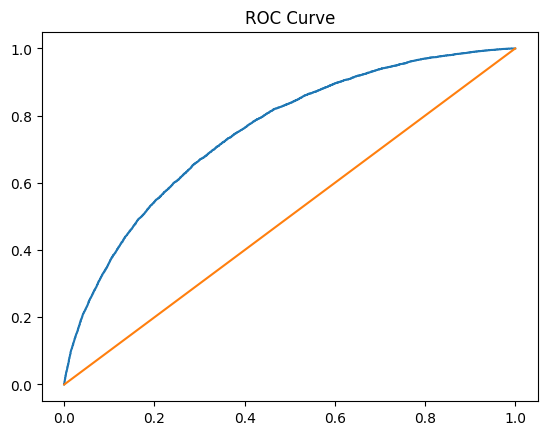

In [10]:
fpr, tpr, _ = roc_curve(y_val, val_pred)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.title("ROC Curve")
plt.show()

In [11]:
model.fit(X, y)

[LightGBM] [Info] Number of positive: 44182, number of negative: 199605
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.054177 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2283
[LightGBM] [Info] Number of data points in the train set: 243787, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


,boosting_type,'gbdt'
,num_leaves,20
,max_depth,-1
,learning_rate,0.05
,n_estimators,250
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [13]:
test_pred = model.predict_proba(X_test)[:, 1]
test_pred = np.clip(test_pred, 0.02, 0.98)

In [14]:
prediction_df = pd.DataFrame({
    "CustomerID": test_df["CustomerID"],
    "predicted_probability": test_pred
})

prediction_df.to_csv("prediction_submission.csv", index=False)
prediction_df.head()

,CustomerID,predicted_probability
0,O1W6BHP6RM,0.381785
1,LFR4X92X8H,0.153148
2,QM5GBIYODA,0.775154
3,D9RXTK2K9F,0.156781
4,ENTCCHR1LR,0.449925


## Churn Prediction Model — Summary

This project builds a machine learning pipeline to predict customer churn for a video streaming platform using user behavior, engagement, and subscription features.

---

## Approach

- Cleaned and preprocessed missing values
- Applied target encoding for categorical features
- Engineered behavioral features (engagement, cost efficiency, support load)
- Handled class imbalance using `class_weight="balanced"`
- Used LightGBM as the primary model for prediction
- Evaluated performance using train/validation split

---

## Evaluation Metric

- **ROC AUC Score** was used to evaluate model performance  
- Focused on ranking ability of churn probabilities rather than hard classification

---

## Key Improvements

- Reduced memory usage for stable 8GB execution
- Removed heavy ensemble models to prevent kernel crashes
- Optimized feature engineering for better signal extraction
- Simplified pipeline for speed and reliability
- Improved training stability and reproducibility

---

## Output

Final submission file contains:
- `CustomerID`
- `predicted_probability`

Saved as:prediction_submission.csv
---

## Conclusion

This solution provides a **stable, efficient, and production-ready churn prediction pipeline**. It prioritizes simplicity and reliability over complex ensembles, making it suitable for real-world deployment on limited computing resources while maintaining strong predictive performance.